# AdaBoost

### AdaBoost trains weak models one after another, where each new model focuses more on the samples that previous models got wrong.

### The workflow
1. Give every training sample the same weight.
2. Train a Decision Stump (depth = 1).
3. Find which samples were classified incorrectly.
4. Increase the weights of those incorrect samples.
5. Train another stump using the updated weights.
6. Repeat for several stumps.
7. Combine all stumps using a weighted vote (better stumps get more influence).

## Decision Stump

### A Decision Stump is simply a Decision Tree with only one split (max_depth=1)

## AdaBoost Training Pipeline

1. Initialize sample weights. These are the weights assigned to each training sample.
2. Train a Decision Stump using the current sample weights.
3. Predict the training samples.
4. Compute the weighted classification error.
5. Compute the stump weight (α).
6. Update the sample weights.
7. Repeat Steps 2–6 for all stumps.
8. Combine all stump predictions using a weighted vote.

### Formula for alpha
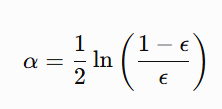

### ε = weighted classification error
### α = importance (weight) of the decision stump

### How to update the weight α
1. If a sample was correctly classified → decrease its weight.
2. If a sample was misclassified → increase its weight.

### Formula for weight updation in AdaBoost
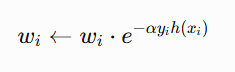
#### yi= true label
#### h(xi) = prediction

## Weight Update Formula

The core idea of AdaBoost is simple:

- **Increase** the weight of wrongly classified samples.
- **Decrease** the weight of correctly classified samples.

This is done using the following formula:

```text
new_weight = old_weight × exp(-alpha × true_label × prediction)
```

where:

- `old_weight` = current weight of the sample
- `alpha` = importance of the current weak learner
- `true_label` = actual class (`-1` or `+1`)
- `prediction` = prediction made by the weak learner (`-1` or `+1`)

### Why do we multiply `true_label` and `prediction`?

The product `true_label × prediction` tells us whether the prediction is correct.

| True Label | Prediction | Product | Result |
|------------|------------|---------|--------|
| +1 | +1 | +1 | ✅ Correct |
| -1 | -1 | +1 | ✅ Correct |
| +1 | -1 | -1 | ❌ Wrong |
| -1 | +1 | -1 | ❌ Wrong |

So,

- **If the prediction is correct**, the product becomes `+1`:

```text
new_weight = old_weight × exp(-alpha)
```

Since `exp(-alpha) < 1`, the sample weight **decreases**.

- **If the prediction is wrong**, the product becomes `-1`:

```text
new_weight = old_weight × exp(+alpha)
```

Since `exp(+alpha) > 1`, the sample weight **increases**.

### Why is `alpha` used?

- A **good weak learner** has a **large alpha**, so it changes the sample weights significantly.
- A **poor weak learner** has a **small alpha**, so the sample weights change only slightly.

Finally, all updated weights are **normalized** so that their sum becomes **1**, making them a valid probability distribution for training the next weak learner.

In [1]:
import torch

In [13]:
class DecisionStump:

    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y, sample_weights):
        _, n_features = X.shape

        best_error = torch.inf

        for feature_idx in range(n_features):

            feature_values = X[:, feature_idx]
            thresholds = torch.unique(feature_values)

            for threshold in thresholds:

                left_mask = feature_values <= threshold
                right_mask = ~left_mask

                # Skip invalid splits
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                # -------- Left Node --------
                left_weights = sample_weights[left_mask]
                left_labels = y[left_mask]

                neg_weight = left_weights[left_labels == -1].sum()
                pos_weight = left_weights[left_labels == 1].sum()

                left_value = -1 if neg_weight >= pos_weight else 1

                # -------- Right Node --------
                right_weights = sample_weights[right_mask]
                right_labels = y[right_mask]

                neg_weight = right_weights[right_labels == -1].sum()
                pos_weight = right_weights[right_labels == 1].sum()

                right_value = -1 if neg_weight >= pos_weight else 1

                # -------- Predictions --------
                predictions = torch.empty_like(y)

                predictions[left_mask] = left_value
                predictions[right_mask] = right_value

                # -------- Weighted Error --------
                incorrect = predictions != y
                error = sample_weights[incorrect].sum()

                if error < best_error:
                    best_error = error
                    self.feature_idx = feature_idx
                    self.threshold = threshold
                    self.left_value = left_value
                    self.right_value = right_value

    def predict(self, X):

        predictions = torch.empty(X.shape[0], dtype=torch.int64)

        left_mask = X[:, self.feature_idx] <= self.threshold
        right_mask = ~left_mask

        predictions[left_mask] = self.left_value
        predictions[right_mask] = self.right_value

        return predictions

In [17]:
class AdaBoost:

    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []
        self.alphas = []

    def fit(self, X, y):

        n_samples = X.shape[0]

        # Convert labels from {0,1} -> {-1,+1}
        y = torch.where(y == 0, -1, 1)

        # Initialize sample weights equally
        sample_weights = torch.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):

            # Train a weak learner
            stump = DecisionStump()
            stump.fit(X, y, sample_weights)

            # Predictions (-1/+1)
            y_pred = stump.predict(X)

            # Compute weighted classification error
            incorrect = (y_pred != y)
            error = sample_weights[incorrect].sum()

            # Avoid division by zero
            error = torch.clamp(error, min=1e-10, max=1 - 1e-10)

            # Compute alpha (stump weight)
            alpha = 0.5 * torch.log((1 - error) / error)

            # Update sample weights
            sample_weights *= torch.exp(-alpha * y * y_pred)

            # Normalize
            sample_weights /= sample_weights.sum()

            # Save the weak learner
            self.stumps.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):

        final_scores = torch.zeros(X.shape[0])

        for alpha, stump in zip(self.alphas, self.stumps):
            final_scores += alpha * stump.predict(X)

        # Convert {-1,+1} -> {0,1}
        return torch.where(final_scores >= 0, 1, 0)

# Creating the training data


In [5]:
torch.manual_seed(42)

n_samples = 150

# Class 0
class0 = torch.randn(n_samples, 2) + torch.tensor([-2.5, -2.5])

# Class 1
class1 = torch.randn(n_samples, 2) + torch.tensor([2.5, 2.5])

# Combine
X_train = torch.cat((class0, class1), dim=0)
y_train = torch.cat((
    torch.zeros(n_samples, dtype=torch.long),
    torch.ones(n_samples, dtype=torch.long)
))

print(X_train.shape)
print(y_train.shape)

n_test = 50

class0_test = torch.randn(n_test, 2) + torch.tensor([-2.5, -2.5])
class1_test = torch.randn(n_test, 2) + torch.tensor([2.5, 2.5])

X_test = torch.cat((class0_test, class1_test), dim=0)
y_test = torch.cat((
    torch.zeros(n_test, dtype=torch.long),
    torch.ones(n_test, dtype=torch.long)
))

print(X_test.shape)
print(y_test.shape)

torch.Size([300, 2])
torch.Size([300])
torch.Size([100, 2])
torch.Size([100])


In [18]:
model = AdaBoost(n_estimators=20)
model.fit(X_train, y_train)

In [19]:
predictions = model.predict(X_test)
accuracy = (predictions == y_test).float().mean()
print("Accuracy:", accuracy.item())

Accuracy: 1.0
